In [1]:
import pandas as pd

df = pd.read_csv("datasets/cyclistic_tripdata_2021.csv", nrows=10000)
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,31FAE55254BEE127,classic_bike,2021-02-12 09:40:15 UTC,2021-02-12 13:28:31 UTC,Fairbanks Ct & Grand Ave,TA1305000003,NaN,NaN,41.891847,-87.620580,NaN,NaN,casual
1,ED658F5C9D645C49,classic_bike,2021-02-14 18:41:23 UTC,2021-02-15 14:08:36 UTC,Clark St & Wrightwood Ave,TA1305000014,NaN,NaN,41.929546,-87.643118,NaN,NaN,member
2,AB91DE991455DBCB,classic_bike,2021-02-14 17:45:13 UTC,2021-02-15 18:45:08 UTC,Clark St & Lake St,KA1503000012,NaN,NaN,41.886021,-87.630876,NaN,NaN,member
3,6E37DC248B3CFE21,classic_bike,2021-02-20 14:34:21 UTC,2021-02-21 15:34:15 UTC,Columbus Dr & Randolph St,13263,NaN,NaN,41.884728,-87.619521,NaN,NaN,member
4,985662404D86B374,classic_bike,2021-02-27 13:22:20 UTC,2021-02-28 14:22:14 UTC,Clark St & Drummond Pl,TA1307000142,NaN,NaN,41.931248,-87.644336,NaN,NaN,casual


Calculate ride duration

In [2]:
df["started_at"] = pd.to_datetime(df["started_at"], utc=True)
df["ended_at"] = pd.to_datetime(df["ended_at"], utc=True)


In [3]:
df["ride_length"] = df["ended_at"] - df["started_at"]
df["ride_length_minutes"] = df["ride_length"].dt.total_seconds() / 60
df.head()


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,ride_length_minutes
0,31FAE55254BEE127,classic_bike,2021-02-12 09:40:15+00:00,2021-02-12 13:28:31+00:00,Fairbanks Ct & Grand Ave,TA1305000003,NaN,NaN,41.891847,-87.620580,NaN,NaN,casual,0 days 03:48:16,228.266667
1,ED658F5C9D645C49,classic_bike,2021-02-14 18:41:23+00:00,2021-02-15 14:08:36+00:00,Clark St & Wrightwood Ave,TA1305000014,NaN,NaN,41.929546,-87.643118,NaN,NaN,member,0 days 19:27:13,1167.216667
2,AB91DE991455DBCB,classic_bike,2021-02-14 17:45:13+00:00,2021-02-15 18:45:08+00:00,Clark St & Lake St,KA1503000012,NaN,NaN,41.886021,-87.630876,NaN,NaN,member,1 days 00:59:55,1499.916667
3,6E37DC248B3CFE21,classic_bike,2021-02-20 14:34:21+00:00,2021-02-21 15:34:15+00:00,Columbus Dr & Randolph St,13263,NaN,NaN,41.884728,-87.619521,NaN,NaN,member,1 days 00:59:54,1499.900000
4,985662404D86B374,classic_bike,2021-02-27 13:22:20+00:00,2021-02-28 14:22:14+00:00,Clark St & Drummond Pl,TA1307000142,NaN,NaN,41.931248,-87.644336,NaN,NaN,casual,1 days 00:59:54,1499.900000


##quality checks

Looking for missing values
Filter out any negative or >24 hr rides

In [4]:
missing_values = df.isna().sum().sort_values(ascending=False)
print("Missing values per column:\n", missing_values)

print("\nRide length (minutes) summary:")
print(df["ride_length_minutes"].describe())

max_duration_minutes = 24 * 60
mask_valid_duration = (df["ride_length_minutes"] > 0) & (df["ride_length_minutes"] <= max_duration_minutes)

print("\nNumber of rides before filtering:", len(df))
print("Number of rides after filtering:", mask_valid_duration.sum())

df_clean = df[mask_valid_duration].copy()

Missing values per column:
 end_station_name       1033
end_station_id         1033
start_station_name      876
start_station_id        876
end_lat                  16
end_lng                  16
started_at                0
ended_at                  0
ride_id                   0
rideable_type             0
start_lat                 0
start_lng                 0
member_casual             0
ride_length               0
ride_length_minutes       0
dtype: int64

Ride length (minutes) summary:
count    10000.000000
mean        20.634535
std        307.618286
min          0.000000
25%          5.933333
50%          9.850000
75%         17.516667
max      30129.233333
Name: ride_length_minutes, dtype: float64

Number of rides before filtering: 10000
Number of rides after filtering: 9989


## Member vs casual
Compare ride lengths and trip counts between members and casual riders

In [ ]:
ride_length_summary = df_clean.groupby("member_casual")["ride_length_minutes"].describe()
print("Ride length (minutes) by user type:\n", ride_length_summary)

trip_counts = df_clean["member_casual"].value_counts().rename("trip_count")
trip_share = df_clean["member_casual"].value_counts(normalize=True).rename("share")

print("\nTrip share by user type:\n", (trip_share * 100).round(2).astype(str) + "%")

Ride length (minutes) by user type:
                 count       mean        std       min    25%        50%  \
member_casual                                                             
casual         1986.0  26.531898  74.601110  0.116667  7.800  13.925000   
member         8003.0  13.716102  30.930516  0.016667  5.625   9.166667   

                   75%          max  
member_casual                        
casual         25.6625  1427.633333  
member         15.8000  1308.100000  

Trip share by user type:
 member_casual
member    80.12%
casual    19.88%
Name: share, dtype: str


In [11]:
# Create hour and day-of-week columns for time-based analysis

df_clean["hour"] = df_clean["started_at"].dt.hour
df_clean["day_of_week"] = df_clean["started_at"].dt.day_name()

df_clean[["started_at", "hour", "day_of_week"]].head()

,started_at,hour,day_of_week
0,2021-02-12 09:40:15+00:00,9,Friday
1,2021-02-14 18:41:23+00:00,18,Sunday
5,2021-02-17 16:21:59+00:00,16,Wednesday
6,2021-02-06 06:31:54+00:00,6,Saturday
8,2021-02-18 17:17:23+00:00,17,Thursday


## Time and Day patterns

examine how rides vary by hour of day and day of week for members vs casual riders



its pretty clear to see that members are commuting to and from work, it looks like casual users are more likely tourists just staking leisurely rides around the city.

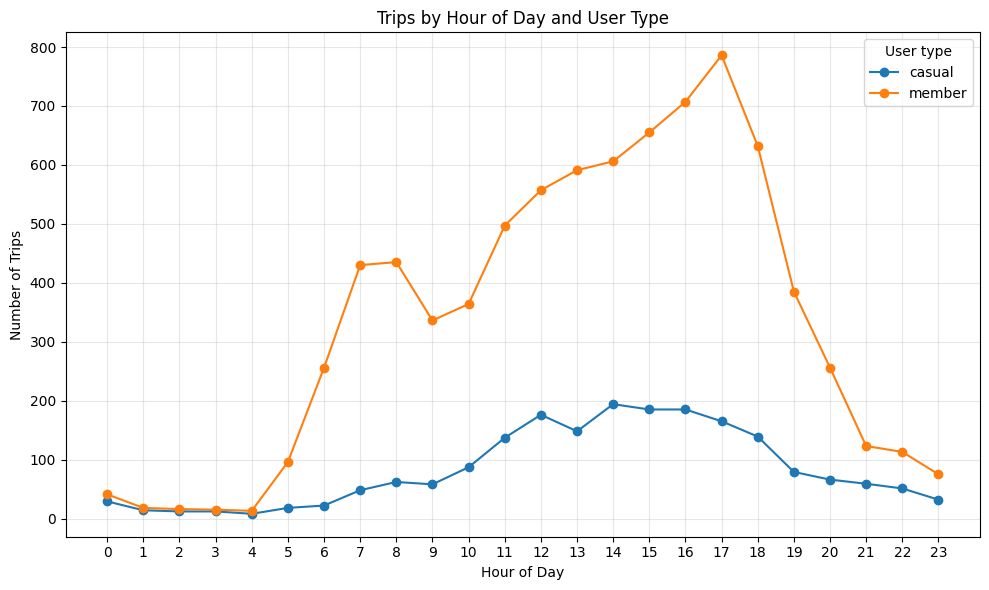

<Figure size 1000x600 with 0 Axes>

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline

hourly_counts = df_clean.groupby(["hour", "member_casual"]).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
for user_type in hourly_counts.columns:
    plt.plot(hourly_counts.index, hourly_counts[user_type], marker="o", label=user_type)

plt.title("Trips by Hour of Day and User Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(0, 24))
plt.legend(title="User type")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_counts = (
    df_clean.groupby(["day_of_week", "member_casual"]).size().unstack(fill_value=0).reindex(day_order))

plt.figure(figsize=(10, 6))
bar_width = 0.35
x = range(len(day_order))


Complete weekday bar chart for members vs casual riders

we can see saturday is extra busy for casual users which supports the theory they are tourists trying to view the city

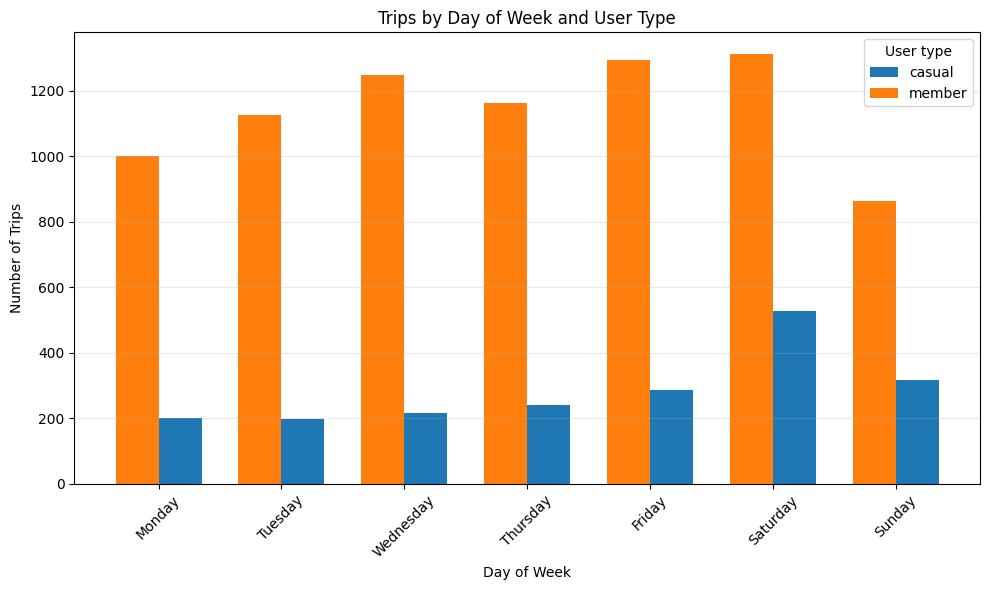

In [ ]:
# 

member_counts = weekday_counts["member"]
casual_counts = weekday_counts["casual"]

plt.figure(figsize=(10, 6))
plt.bar([i + bar_width / 2 for i in x], casual_counts, width=bar_width, label="casual")
plt.bar([i - bar_width / 2 for i in x], member_counts, width=bar_width, label="member")


plt.title("Trips by Day of Week and User Type")
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.xticks(list(x), day_order, rotation=45)
plt.legend(title="User type")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Ride length distributions

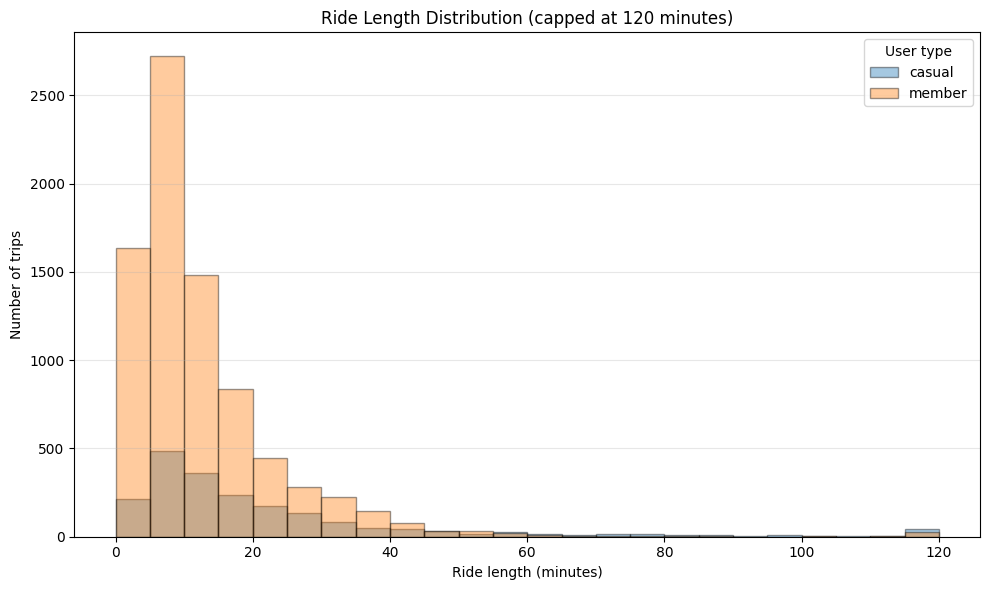

In [30]:
# Histogram of ride length (minutes) by user type

max_minutes = 120  # cap at 2 hours to ignore long tail
bins = range(0, max_minutes + 5, 5)

plt.figure(figsize=(10, 6))
for user_type, color in [("casual", "tab:red"), ("member", "tab:orange")]:
    subset = df_clean[df_clean["member_casual"] == user_type]
    plt.hist(
        subset["ride_length_minutes"].clip(upper=max_minutes),
        bins=bins,
        alpha=0.4,
        label=user_type,
        edgecolor="black",
    )

plt.title("Ride Length Distribution (capped at 120 minutes)")
plt.xlabel("Ride length (minutes)")
plt.ylabel("Number of trips")
plt.legend(title="User type")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Bike type usage

Bike type x user type (counts):
 member_casual  casual  member
rideable_type                
classic_bike     1033    5842
docked_bike       249       0
electric_bike     704    2161

Bike type x user type (row %):
 member_casual  casual  member
rideable_type                
classic_bike     15.0    85.0
docked_bike     100.0     0.0
electric_bike    24.6    75.4


<Figure size 800x600 with 0 Axes>

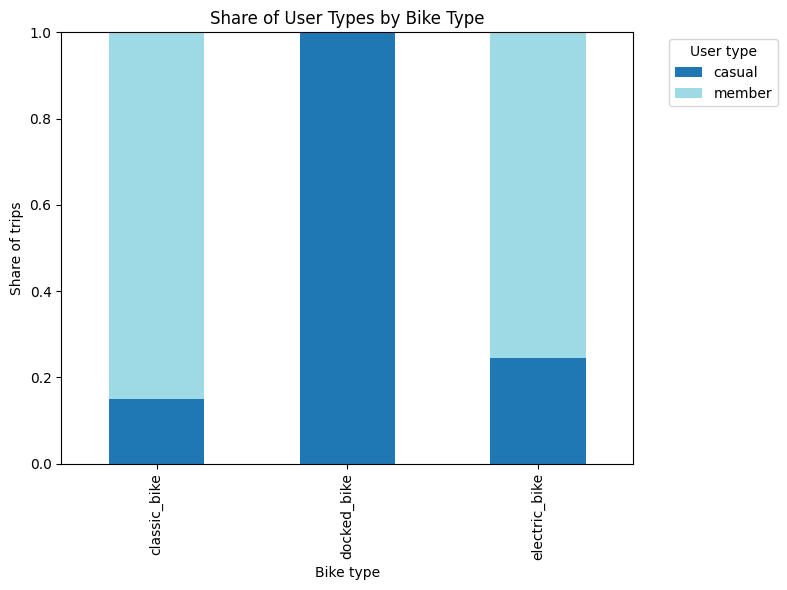


Average ride length (minutes) by bike type and user type:
 member_casual  casual  member
rideable_type                
classic_bike     26.9    14.1
docked_bike      56.3     NaN
electric_bike    15.5    12.6


In [31]:
# Crosstab of bike type by user type

bike_user_ct = pd.crosstab(df_clean["rideable_type"], df_clean["member_casual"])
print("Bike type x user type (counts):\n", bike_user_ct)
print("\nBike type x user type (row %):\n", (bike_user_ct.div(bike_user_ct.sum(axis=1), axis=0) * 100).round(1))

# Stacked bar chart
plt.figure(figsize=(8, 6))
(bike_user_ct
 .div(bike_user_ct.sum(axis=1), axis=0)
 .plot(kind="bar", stacked=True, figsize=(8, 6), colormap="tab20", legend=True))

plt.title("Share of User Types by Bike Type")
plt.xlabel("Bike type")
plt.ylabel("Share of trips")
plt.legend(title="User type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Average ride length by bike type and user type
avg_duration_bike_user = (
    df_clean.groupby(["rideable_type", "member_casual"])["ride_length_minutes"]
    .mean()
    .round(1)
    .unstack()
)
print("\nAverage ride length (minutes) by bike type and user type:\n", avg_duration_bike_user)

## Station-based insights

In [32]:
# Top start and end stations for members vs casual riders

for user_type in ["member", "casual"]:
    print(f"\nTop 10 start stations for {user_type}s:")
    top_start = (
        df_clean[df_clean["member_casual"] == user_type]["start_station_name"]
        .value_counts()
        .head(10)
    )
    print(top_start)

    print(f"\nTop 10 end stations for {user_type}s:")
    top_end = (
        df_clean[df_clean["member_casual"] == user_type]["end_station_name"]
        .value_counts()
        .head(10)
    )
    print(top_end)

# Average ride length by start station and user type (only stations with enough rides)
min_trips_per_station = 30

avg_duration_station = (
    df_clean.groupby(["start_station_name", "member_casual"])["ride_length_minutes"]
    .agg(["count", "mean"])
    .reset_index()
)

# Filter to stations with at least N trips for stability
avg_duration_station = avg_duration_station[avg_duration_station["count"] >= min_trips_per_station]

print("\nAverage ride length (minutes) by start station and user type (>= 30 trips):")
print(avg_duration_station.sort_values("mean", ascending=False).head(20))


Top 10 start stations for members:
start_station_name
Dearborn St & Erie St        82
Clark St & Elm St            78
Wells St & Elm St            78
Wells St & Huron St          74
Desplaines St & Kinzie St    68
Kingsbury St & Kinzie St     67
Clinton St & Madison St      66
Daley Center Plaza           64
St. Clair St & Erie St       64
Columbus Dr & Randolph St    64
Name: count, dtype: int64

Top 10 end stations for members:
end_station_name
Dearborn St & Erie St        102
Clark St & Elm St             93
St. Clair St & Erie St        76
Wabash Ave & Roosevelt Rd     73
Wells St & Elm St             65
Kingsbury St & Kinzie St      63
Clinton St & Madison St       62
Broadway & Barry Ave          59
McClurg Ct & Erie St          58
Wells St & Concord Ln         56
Name: count, dtype: int64

Top 10 start stations for casuals:
start_station_name
Lake Shore Dr & Monroe St    29
Ellis Ave & 60th St          25
Millennium Park              25
Streeter Dr & Grand Ave      19
Daley Cen

## Time-of-day × day-of-week heatmaps

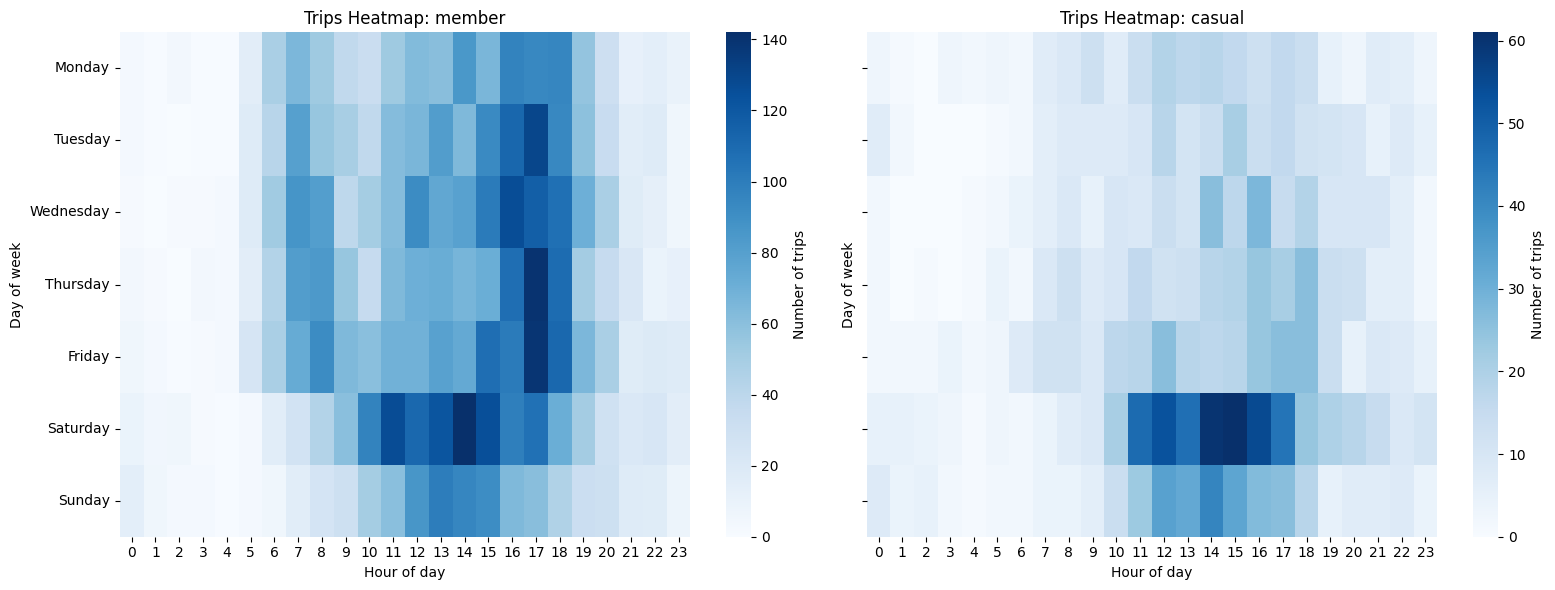

In [34]:
import seaborn as sns

# Ensure day_of_week is ordered
cat_type = pd.CategoricalDtype(categories=day_order, ordered=True)
df_clean["day_of_week"] = df_clean["day_of_week"].astype(cat_type)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, user_type in zip(axes, ["member", "casual"]):
    subset = df_clean[df_clean["member_casual"] == user_type]
    pivot = subset.pivot_table(
        index="day_of_week",
        columns="hour",
        values="ride_id",
        aggfunc="count",
        fill_value=0,
    )

    sns.heatmap(
        pivot,
        ax=ax,
        cmap="Blues",
        cbar_kws={"label": "Number of trips"},
    )
    ax.set_title(f"Trips Heatmap: {user_type}")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Day of week")

plt.tight_layout()
plt.show()

## Segment comparisons for business insights

In [35]:
# Weekend vs weekday, commute vs leisure, and ride length bands

# Weekend flag
df_clean["is_weekend"] = df_clean["day_of_week"].isin(["Saturday", "Sunday"])

# Commute vs non-commute hours (simple rule of thumb)
commute_hours = list(range(6, 10)) + list(range(16, 20))
df_clean["is_commute_hour"] = df_clean["hour"].isin(commute_hours)

# Ride length bands
bins = [0, 15, 45, float("inf")]
labels = ["short (≤15m)", "medium (15–45m)", "long (>45m)"]
df_clean["duration_band"] = pd.cut(df_clean["ride_length_minutes"], bins=bins, labels=labels, right=True)

# Weekend vs weekday summary
weekend_summary = (
    df_clean
    .groupby(["member_casual", "is_weekend"])["ride_id"]
    .count()
    .unstack(fill_value=0)
)
print("Weekend vs weekday trips by user type:\n", weekend_summary)

# Commute hour vs other hours
commute_summary = (
    df_clean
    .groupby(["member_casual", "is_commute_hour"])["ride_id"]
    .count()
    .unstack(fill_value=0)
)
print("\nCommute-hour vs other-hour trips by user type:\n", commute_summary)

# Ride length band distribution
band_summary = pd.crosstab(df_clean["member_casual"], df_clean["duration_band"], normalize="index") * 100
print("\nRide length bands (% of trips) by user type:\n", band_summary.round(1))

Weekend vs weekday trips by user type:
 is_weekend     False  True 
member_casual              
casual          1141    845
member          5827   2176

Commute-hour vs other-hour trips by user type:
 is_commute_hour  False  True 
member_casual                
casual            1228    758
member            4036   3967

Ride length bands (% of trips) by user type:
 duration_band  short (≤15m)  medium (15–45m)  long (>45m)
member_casual                                            
casual                 53.2             36.5         10.3
member                 73.0             25.1          1.9
